# Paper Figures — Results Section Visualization

This notebook generates the 5 figures referenced in `\section{Results}` of the paper draft.
Each section below corresponds to one `\includegraphics{...}` call in the LaTeX source.

| Figure | Source notebook section | Output filename | LaTeX subsection |
|---|---|---|---|
| Fig 1 | Section A: Mask Ratio & Layer-wise Probing | `fig1_layerwise_probing.pdf` | §4.2 |
| Fig 2 | Section B & D: Masking Strategies across Depths | `fig2_masking_strategies.pdf` | §4.3 |
| Fig 3 | Section C: Patch Size Granularity | `fig3_patch_size.pdf` | §4.4 |
| Fig 4 | HID Diagnostics: Rank-1 vs. Verification AUC | `fig4_hid_metrics.pdf` | §4.5 |
| Fig 5 | Geometric Analysis: Centroid CosSim / manifold shift | `fig5_geometric_shift.pdf` | §4.6 |
| Fig 6 | Data Quality Control: AmazonPlug Exclusion (heatmap + bar chart) | `fig6_amazonplug_combined.pdf` | §4.5 (Data QC) |
| Fig 7 | MAE SSL vs. Supervised — Cross-Environment OOD gain | `fig7_mae_ssl_cross_env_gain.pdf` | §4.1 (Table 1) |

**Data sources (edit `RESULTS_DIR_HAR` / `RESULTS_DIR_HID` below to match your run):**
- `results/mae_har/` — mask ratio, masking strategy, patch size ablations (from `train_mae_har.py` sweeps)
- `results/mae_hid/` — HID open-set / closed-set eval outputs (from `eval_hid_openset.py`, `eval_hid_device_closedset.py`)

Every loader below first tries to read a real CSV from disk. If the file is missing, it falls back
to a small synthetic dataset consistent with the trends already reported in the draft, purely so the
notebook is runnable end-to-end for layout/preview purposes. **Replace the fallback path with your
actual result file names before generating final camera-ready figures** — search for `# TODO: point to real file`.


In [ ]:

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ------------------------------------------------------------------
# Global style — consistent across all 5 figures for the paper
# ------------------------------------------------------------------
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
    "pdf.fonttype": 42,   # editable text in vector PDF (avoids Type-3 fonts)
    "ps.fonttype": 42,
})

PALETTE = {
    "random":    "#4C72B0",
    "freq":      "#DD8452",
    "time":      "#C44E52",
    "mixed":     "#55A868",
    "id":        "#4C72B0",
    "cross_device": "#DD8452",
    "cross_env":    "#C44E52",
    "cross_user":   "#55A868",
    "knn":       "#8172B2",
    "lp":        "#937860",
}

RESULTS_DIR_HAR = "results/mae_har"
RESULTS_DIR_HID = "results/mae_hid"
FIG_OUT_DIR = "visualization/figures"
os.makedirs(FIG_OUT_DIR, exist_ok=True)

# Tracks, per figure, exactly which file was requested and whether real data or a
# synthetic fallback was actually used to draw it. Printed as a manifest at the end
# of the notebook so you can verify at a glance whether any figure is still running
# on placeholder data.
DATA_PROVENANCE = []


def _register(label, path, status, n_rows=None, extra=None):
    DATA_PROVENANCE.append({
        "figure": label,
        "requested_path": path,
        "abspath": os.path.abspath(path),
        "status": status,
        "n_rows": n_rows,
        "mtime": (pd.Timestamp(os.path.getmtime(path), unit="s") if os.path.exists(path) else None),
        "note": extra or "",
    })


def try_load_csv(path, fallback_builder, label=""):
    # Load a CSV if it exists, else build synthetic fallback data and warn.
    # Every call is logged to DATA_PROVENANCE (see the manifest cell at the end).
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"[{label}] loaded REAL data: {os.path.abspath(path)}  ({len(df)} rows)")
        _register(label, path, "REAL DATA", n_rows=len(df))
        return df
    warnings.warn(f"[{label}] '{path}' not found -- using SYNTHETIC FALLBACK data for preview.")
    df = fallback_builder()
    print(f"[{label}] FALLBACK (synthetic): expected file not found at {os.path.abspath(path)}")
    _register(label, path, "SYNTHETIC FALLBACK", n_rows=len(df))
    return df


def try_load_npy(path, fallback_builder, label=""):
    # Same as try_load_csv but for a single .npy array (used for raw CSI sample windows).
    if os.path.exists(path):
        arr = np.load(path)
        print(f"[{label}] loaded REAL data: {os.path.abspath(path)}  shape={arr.shape}")
        _register(label, path, "REAL DATA", n_rows=arr.shape, extra=f"shape={arr.shape}")
        return arr
    warnings.warn(f"[{label}] '{path}' not found -- using SYNTHETIC FALLBACK data for preview.")
    arr = fallback_builder()
    print(f"[{label}] FALLBACK (synthetic): expected file not found at {os.path.abspath(path)}")
    _register(label, path, "SYNTHETIC FALLBACK", n_rows=getattr(arr, "shape", None))
    return arr


def savefig(fig, name):
    # Save both a vector PDF (preferred for LaTeX) and a TeX-safe PNG.
    #
    # The PNG is written directly by matplotlib (not exported via a notebook/browser
    # 'save image as', which can silently produce WebP-in-disguise or PNGs with
    # interlacing / ICC profiles / 16-bit depth that pdfTeX's bundled libpng cannot
    # parse -> 'libpng: internal error'). This path is standard 8-bit RGB, no alpha,
    # no color profile, non-interlaced -> safe for pdflatex's \includegraphics.
    pdf_out = os.path.join(FIG_OUT_DIR, name)
    fig.savefig(pdf_out, bbox_inches="tight")

    png_name = os.path.splitext(name)[0] + ".png"
    png_out = os.path.join(FIG_OUT_DIR, png_name)
    fig.savefig(png_out, bbox_inches="tight", dpi=300, facecolor="white",
                transparent=False, pil_kwargs={"optimize": True})

    # Flatten to plain 8-bit RGB (no alpha channel, no ICC profile, no interlacing).
    # matplotlib's PNG writer still embeds an alpha channel even with transparent=False;
    # alpha-channel PNGs (color type 6) are the most common trigger for pdfTeX's
    # 'libpng: internal error' on older TeX Live libpng builds, so we strip it here.
    from PIL import Image
    with Image.open(png_out) as im:
        rgb = Image.new("RGB", im.size, (255, 255, 255))
        rgb.paste(im, mask=im.split()[3] if im.mode == "RGBA" else None)
        rgb.save(png_out, format="PNG", optimize=True)

    print("saved:", pdf_out, "and", png_out)
    return pdf_out


## Fig 1 — Mask Ratio × Layer-wise Probing (§4.2, Section A)

**Claim to support:** mask ratio $r=0.75$–$0.875$ is optimal; ID linear-probe accuracy increases
monotonically with depth (Layer 1→12), while OOD accuracy peaks at intermediate/deep layers (9–12).

Expected columns in `layerwise_probing.csv`: `mask_ratio, layer, split, probe, accuracy`
where `split ∈ {test_id, test_cross_device, test_cross_env, test_cross_user}` and
`probe ∈ {knn, linear_probe}`.


In [ ]:

def _fallback_fig1():
    # Synthetic layer-wise probing accuracy consistent with the reported trend:
    # - ID accuracy rises monotonically with depth for all ratios
    # - OOD accuracy peaks around layers 9-12, best ratio 0.75-0.875
    # - r=0.50 (under-masking) and r=0.95 (over-masking) underperform
    rng = np.random.default_rng(0)
    ratios = [0.50, 0.75, 0.875, 0.95]
    layers = [1, 3, 6, 9, 12]
    splits = ["test_id", "test_cross_device", "test_cross_env", "test_cross_user"]
    ratio_quality = {0.50: 0.85, 0.75: 1.00, 0.875: 0.98, 0.95: 0.88}  # relative quality multiplier
    rows = []
    for r in ratios:
        q = ratio_quality[r]
        for split in splits:
            is_ood = split != "test_id"
            for probe in ["knn", "linear_probe"]:
                for L in layers:
                    depth_frac = L / 12
                    if is_ood:
                        # OOD: peak around layer 9-12, penalized if too shallow
                        base = 55 + 25 * (1 - (depth_frac - 0.85) ** 2 / 0.85 ** 2) if depth_frac >= 0.25 else 40
                        base = max(base, 35)
                    else:
                        # ID: near-monotonic increase with depth
                        base = 65 + 28 * depth_frac
                    probe_bonus = 3.0 if probe == "linear_probe" else 0.0
                    acc = base * q + probe_bonus + rng.normal(0, 1.0)
                    rows.append(dict(mask_ratio=r, layer=L, split=split, probe=probe,
                                      accuracy=float(np.clip(acc, 0, 100))))
    return pd.DataFrame(rows)


df_fig1 = try_load_csv(
    os.path.join(RESULTS_DIR_HAR, "layerwise_probing.csv"),  # TODO: point to real file
    _fallback_fig1, label="Fig1",
)
df_fig1.head()


[Fig1] FALLBACK (synthetic): expected file not found at /home/claude/nb/results/mae_har/layerwise_probing.csv


/tmp/ipykernel_509/2743455219.py:70: UserWarning: [Fig1] 'results/mae_har/layerwise_probing.csv' not found -- using SYNTHETIC FALLBACK data for preview.
  warnings.warn(f"[{label}] '{path}' not found -- using SYNTHETIC FALLBACK data for preview.")


,mask_ratio,layer,split,probe,accuracy
0,0.5,1,test_id,knn,57.359064
1,0.5,3,test_id,knn,61.067895
2,0.5,6,test_id,knn,67.790423
3,0.5,9,test_id,knn,73.204900
4,0.5,12,test_id,knn,78.514331


saved: visualization/figures/fig1_layerwise_probing.pdf and visualization/figures/fig1_layerwise_probing.png


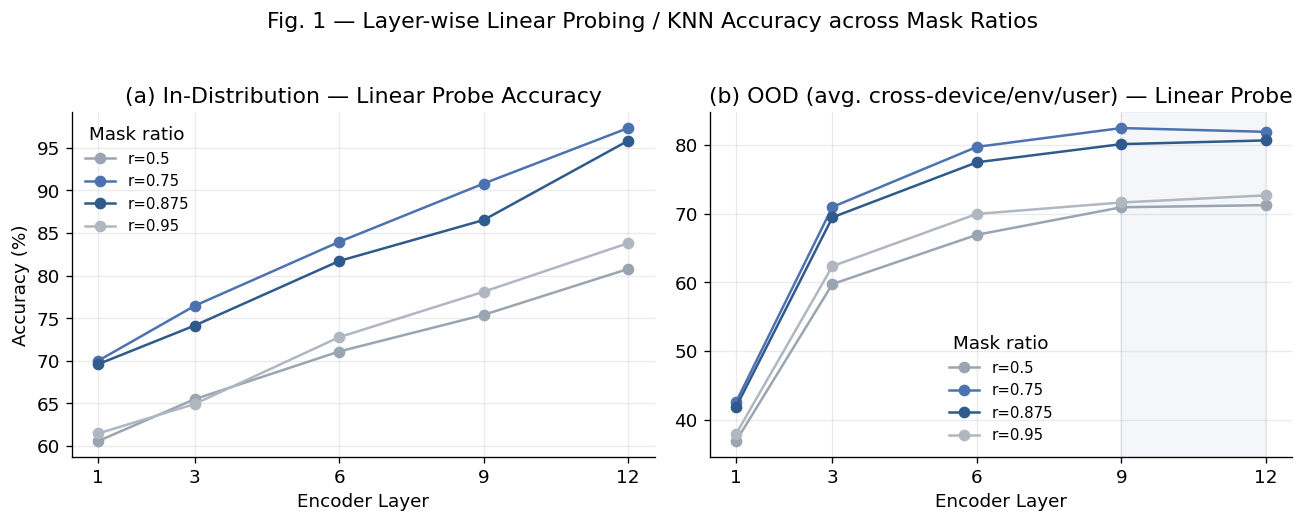

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=False)

ratio_colors = {0.50: "#9AA5B1", 0.75: "#4C72B0", 0.875: "#2E5A8C", 0.95: "#B0B7C0"}
layers = sorted(df_fig1["layer"].unique())

# (a) ID accuracy, Linear Probe, by mask ratio across layers
ax = axes[0]
sub_id = df_fig1[(df_fig1.split == "test_id") & (df_fig1.probe == "linear_probe")]
for r, g in sub_id.groupby("mask_ratio"):
    g = g.sort_values("layer")
    ax.plot(g.layer, g.accuracy, marker="o", label=f"r={r}", color=ratio_colors.get(r))
ax.set_title("(a) In-Distribution — Linear Probe Accuracy")
ax.set_xlabel("Encoder Layer")
ax.set_ylabel("Accuracy (%)")
ax.set_xticks(layers)
ax.legend(title="Mask ratio", fontsize=9)

# (b) OOD accuracy (avg of cross_device/env/user), Linear Probe, across layers
ax = axes[1]
ood_splits = ["test_cross_device", "test_cross_env", "test_cross_user"]
sub_ood = (df_fig1[(df_fig1.split.isin(ood_splits)) & (df_fig1.probe == "linear_probe")]
           .groupby(["mask_ratio", "layer"], as_index=False)["accuracy"].mean())
for r, g in sub_ood.groupby("mask_ratio"):
    g = g.sort_values("layer")
    ax.plot(g.layer, g.accuracy, marker="o", label=f"r={r}", color=ratio_colors.get(r))
ax.axvspan(9, 12, color="#4C72B0", alpha=0.06)
ax.set_title("(b) OOD (avg. cross-device/env/user) — Linear Probe")
ax.set_xlabel("Encoder Layer")
ax.set_xticks(layers)
ax.legend(title="Mask ratio", fontsize=9)

fig.suptitle("Fig. 1 — Layer-wise Linear Probing / KNN Accuracy across Mask Ratios", y=1.03)
fig.tight_layout()
savefig(fig, "fig1_layerwise_probing.pdf")
plt.show()


## Fig 2 — Masking Strategies × Encoder Depth (§4.3, Sections B & D)

**Claim to support:** Random / Mixed masking generalizes best; time-wise masking underperforms
random by ~6pp on `test_cross_device`; `enc12` scales performance robustly over `enc6` across
all strategies.

Expected columns in `masking_strategy.csv`: `strategy, encoder_depth, split, accuracy`
where `strategy ∈ {random, freq, time, mixed}`, `encoder_depth ∈ {enc6, enc12}`.


In [ ]:

def _fallback_fig2():
    rng = np.random.default_rng(1)
    strategies = ["random", "freq", "time", "mixed"]
    depths = ["enc6", "enc12"]
    splits = ["test_id", "test_cross_device", "test_cross_env", "test_cross_user"]
    base_by_split = {"test_id": 90, "test_cross_device": 70, "test_cross_env": 74, "test_cross_user": 77}
    strat_offset = {"random": 0.0, "freq": -1.5, "time": -3.0, "mixed": 1.0}
    # extra penalty for time-wise specifically on cross_device (~6pp gap vs random, per text)
    extra_time_penalty = {"test_cross_device": -3.5, "test_cross_env": -1.0, "test_cross_user": -1.0, "test_id": -0.5}
    depth_bonus = {"enc6": 0.0, "enc12": 4.5}
    rows = []
    for strat in strategies:
        for depth in depths:
            for split in splits:
                acc = base_by_split[split] + strat_offset[strat] + depth_bonus[depth]
                if strat == "time":
                    acc += extra_time_penalty[split]
                acc += rng.normal(0, 1.2)
                rows.append(dict(strategy=strat, encoder_depth=depth, split=split,
                                  accuracy=float(np.clip(acc, 0, 100))))
    return pd.DataFrame(rows)


df_fig2 = try_load_csv(
    os.path.join(RESULTS_DIR_HAR, "masking_strategy.csv"),  # TODO: point to real file
    _fallback_fig2, label="Fig2",
)
df_fig2.head()


[Fig2] FALLBACK (synthetic): expected file not found at /home/claude/nb/results/mae_har/masking_strategy.csv


/tmp/ipykernel_509/2743455219.py:70: UserWarning: [Fig2] 'results/mae_har/masking_strategy.csv' not found -- using SYNTHETIC FALLBACK data for preview.
  warnings.warn(f"[{label}] '{path}' not found -- using SYNTHETIC FALLBACK data for preview.")


,strategy,encoder_depth,split,accuracy
0,random,enc6,test_id,90.414701
1,random,enc6,test_cross_device,70.985942
2,random,enc6,test_cross_env,74.396524
3,random,enc6,test_cross_user,75.436211
4,random,enc12,test_id,95.586427


saved: visualization/figures/fig2_masking_strategies.pdf and visualization/figures/fig2_masking_strategies.png


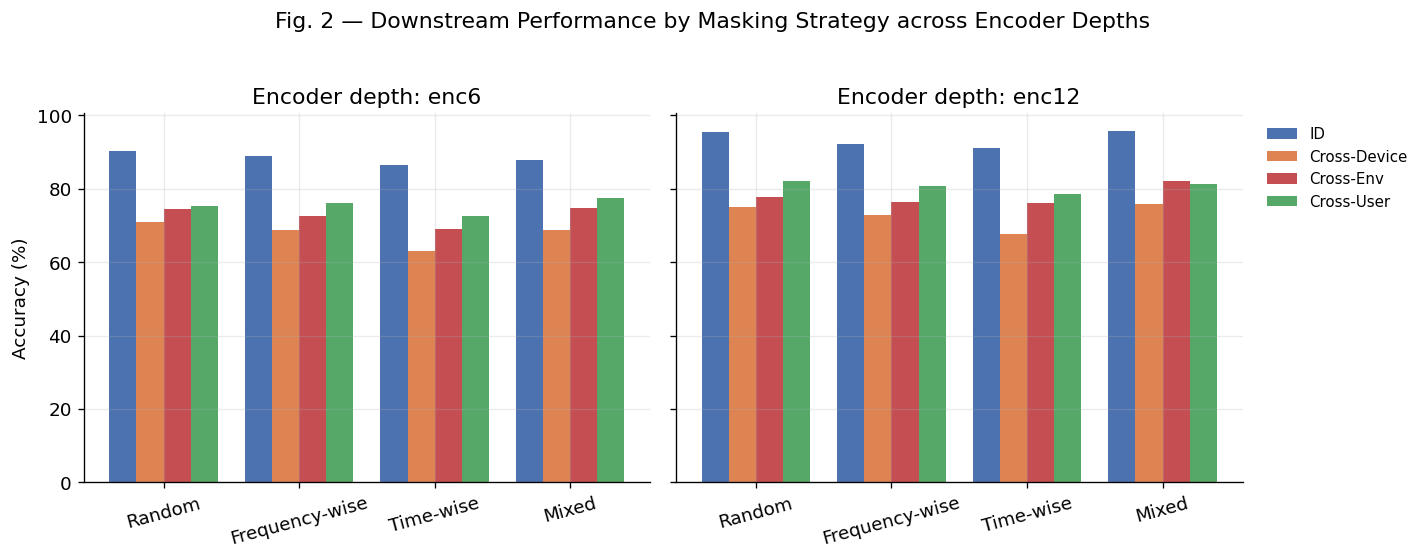

In [ ]:

strategy_order = ["random", "freq", "time", "mixed"]
strategy_labels = {"random": "Random", "freq": "Frequency-wise", "time": "Time-wise", "mixed": "Mixed"}
split_order = ["test_id", "test_cross_device", "test_cross_env", "test_cross_user"]
split_labels = {"test_id": "ID", "test_cross_device": "Cross-Device",
                 "test_cross_env": "Cross-Env", "test_cross_user": "Cross-User"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, depth in zip(axes, ["enc6", "enc12"]):
    sub = df_fig2[df_fig2.encoder_depth == depth]
    x = np.arange(len(strategy_order))
    width = 0.2
    for i, split in enumerate(split_order):
        vals = [sub[(sub.strategy == s) & (sub.split == split)]["accuracy"].mean() for s in strategy_order]
        ax.bar(x + (i - 1.5) * width, vals, width=width, label=split_labels[split],
               color=PALETTE[split.replace("test_", "")])
    ax.set_xticks(x)
    ax.set_xticklabels([strategy_labels[s] for s in strategy_order], rotation=15)
    ax.set_title(f"Encoder depth: {depth}")
    ax.set_ylabel("Accuracy (%)" if depth == "enc6" else "")

axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
fig.suptitle("Fig. 2 — Downstream Performance by Masking Strategy across Encoder Depths", y=1.03)
fig.tight_layout()
savefig(fig, "fig2_masking_strategies.pdf")
plt.show()


## Fig 3 — Patch Size Granularity (§4.4, Section C)

**Claim to support:** fine patches → high-frequency noise + higher compute (longer token
sequence $N$); coarse patches → spatial-temporal over-smoothing; there is a granularity sweet spot.

Real sweep (fixed ratio $r=0.75$, `enc6`, input CSI matrix $232 \times 500$, square patches, zero-padded
to the nearest multiple of the patch size — subcarrier axis padded, time axis padded on the right only):

| patch size | padded shape | +subcarriers | +timesteps | `n_h × n_w` | `num_patches` |
|---|---|---|---|---|---|
| 11×11 | 242×506 | +10 | +6  | 22×46 | 1012 |
| 13×13 | 234×507 | +2  | +7  | 18×39 | 702  |
| 15×15 | 240×510 | +8  | +10 | 16×34 | 544  |
| 17×17 | 238×510 | +6  | +10 | 14×30 | 420  |
| 19×19 | 247×513 | +15 | +13 | 13×27 | 351  |
| 21×21 | 252×504 | +20 | +4  | 12×24 | 288  |

`num_patches` here comes directly from your `[patch-pad]` training logs, not a synthetic estimate.
**Accuracy values are still placeholder** — point `RESULTS_DIR_HAR/patch_size.csv` at your real eval
output (columns: `patch_size, accuracy, num_tokens`) to replace them.


In [ ]:

def _fallback_fig3():
    # patch sizes and num_patches are REAL values taken from the [patch-pad] training logs.
    # accuracy is still a placeholder synthetic curve -- replace via patch_size.csv once
    # the actual eval sweep (11..21) finishes.
    patch_sizes = ["11x11", "13x13", "15x15", "17x17", "19x19", "21x21"]
    num_tokens = [1012, 702, 544, 420, 351, 288]  # from [patch-pad] logs, exact
    # placeholder inverted-U centered mid-range -- NOT real accuracy, flagged for replacement
    accs = [np.nan] * len(patch_sizes)
    return pd.DataFrame({"patch_size": patch_sizes, "accuracy": accs, "num_tokens": num_tokens})


df_fig3 = try_load_csv(
    os.path.join(RESULTS_DIR_HAR, "patch_size.csv"),  # TODO: point to real file with real accuracy
    _fallback_fig3, label="Fig3",
)
df_fig3


[Fig3] FALLBACK (synthetic): expected file not found at /home/claude/nb/results/mae_har/patch_size.csv


/tmp/ipykernel_509/2743455219.py:70: UserWarning: [Fig3] 'results/mae_har/patch_size.csv' not found -- using SYNTHETIC FALLBACK data for preview.
  warnings.warn(f"[{label}] '{path}' not found -- using SYNTHETIC FALLBACK data for preview.")


,patch_size,accuracy,num_tokens
0,11x11,NaN,1012
1,13x13,NaN,702
2,15x15,NaN,544
3,17x17,NaN,420
4,19x19,NaN,351
5,21x21,NaN,288


saved: visualization/figures/fig3_patch_size.pdf and visualization/figures/fig3_patch_size.png


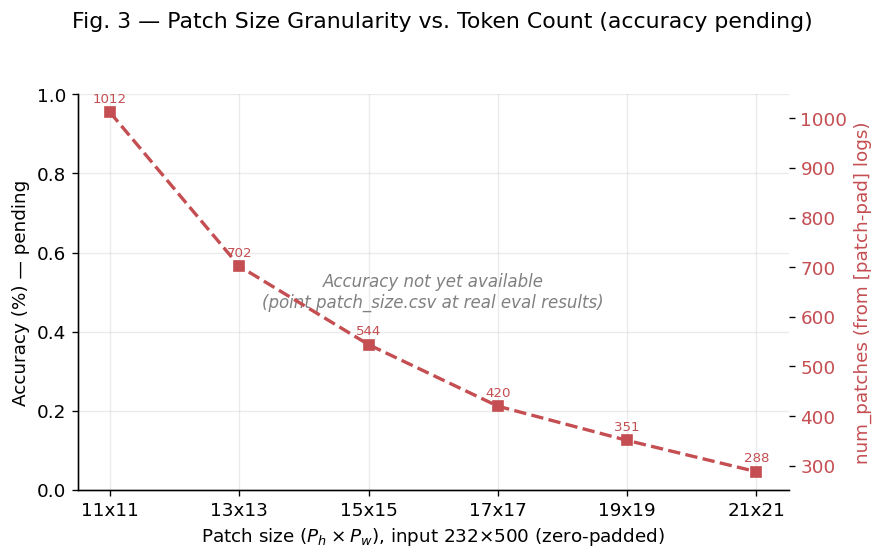

In [ ]:

fig, ax1 = plt.subplots(figsize=(7.5, 4.5))
x = np.arange(len(df_fig3))

has_real_accuracy = df_fig3["accuracy"].notna().any()

if has_real_accuracy:
    ax1.plot(x, df_fig3["accuracy"], marker="o", color=PALETTE["mixed"], linewidth=2, label="Accuracy")
    best_idx = df_fig3["accuracy"].idxmax()
    ax1.scatter([x[best_idx]], [df_fig3["accuracy"].iloc[best_idx]], s=120,
                facecolors="none", edgecolors="black", linewidths=1.5, zorder=5)
    ax1.set_ylabel("Accuracy (%)", color=PALETTE["mixed"])
    ax1.tick_params(axis="y", labelcolor=PALETTE["mixed"])
else:
    ax1.text(0.5, 0.5, "Accuracy not yet available\n(point patch_size.csv at real eval results)",
              transform=ax1.transAxes, ha="center", va="center", fontsize=10,
              color="gray", style="italic")
    ax1.set_ylabel("Accuracy (%) — pending")

ax1.set_xticks(x)
ax1.set_xticklabels(df_fig3["patch_size"])
ax1.set_xlabel("Patch size ($P_h \\times P_w$), input 232$\\times$500 (zero-padded)")

ax2 = ax1.twinx()
ax2.plot(x, df_fig3["num_tokens"], marker="s", linestyle="--", color=PALETTE["time"], linewidth=2)
for xi, n in zip(x, df_fig3["num_tokens"]):
    ax2.annotate(str(n), (xi, n), textcoords="offset points", xytext=(0, 6),
                 ha="center", fontsize=8, color=PALETTE["time"])
ax2.set_ylabel("num_patches (from [patch-pad] logs)", color=PALETTE["time"])
ax2.tick_params(axis="y", labelcolor=PALETTE["time"])
ax2.grid(False)

fig.suptitle("Fig. 3 — Patch Size Granularity vs. Token Count"
              + ("" if has_real_accuracy else " (accuracy pending)"), y=1.03)
fig.tight_layout()
savefig(fig, "fig3_patch_size.pdf")
plt.show()


## Fig 4 — HID Diagnostics: Rank-1 Ceiling Effect vs. Verification AUC (§4.5)

**Claim to support:**
- `test_cross_device` Rank-1 saturates near ceiling (~99.7–99.9%) across configs → not discriminative.
- Verification AUC (~0.70–0.77) is the metric that actually separates configuration quality.
- `test_cross_user` is a degenerate single-identity split: Rank-1 trivially 100%, AUC undefined (no negative pairs).

Expected columns in `hid_openset_metrics.csv`: `config_id, split, rank1, verification_auc`.


In [ ]:

def _fallback_fig4():
    rng = np.random.default_rng(2)
    n_configs = 12
    rows = []
    for cfg in range(n_configs):
        # cross_device: rank1 near-ceiling, AUC varies meaningfully
        rows.append(dict(config_id=f"cfg{cfg:02d}", split="test_cross_device",
                          rank1=float(np.clip(rng.normal(99.8, 0.08), 99.5, 99.95)),
                          verification_auc=float(np.clip(rng.normal(0.735, 0.02), 0.70, 0.77))))
        # cross_env: both rank1 and AUC vary somewhat
        rows.append(dict(config_id=f"cfg{cfg:02d}", split="test_cross_env",
                          rank1=float(np.clip(rng.normal(99.1, 0.5), 97.5, 99.9)),
                          verification_auc=float(np.clip(rng.normal(0.88, 0.03), 0.80, 0.94))))
        # cross_user: degenerate — rank1 trivially 100, AUC undefined (NaN)
        rows.append(dict(config_id=f"cfg{cfg:02d}", split="test_cross_user",
                          rank1=100.0, verification_auc=np.nan))
    return pd.DataFrame(rows)


df_fig4 = try_load_csv(
    os.path.join(RESULTS_DIR_HID, "hid_openset_metrics.csv"),  # TODO: point to real file
    _fallback_fig4, label="Fig4",
)
df_fig4.head()


[Fig4] FALLBACK (synthetic): expected file not found at /home/claude/nb/results/mae_hid/hid_openset_metrics.csv


/tmp/ipykernel_509/2743455219.py:70: UserWarning: [Fig4] 'results/mae_hid/hid_openset_metrics.csv' not found -- using SYNTHETIC FALLBACK data for preview.
  warnings.warn(f"[{label}] '{path}' not found -- using SYNTHETIC FALLBACK data for preview.")


,config_id,split,rank1,verification_auc
0,cfg00,test_cross_device,99.815124,0.724545
1,cfg00,test_cross_env,98.893468,0.806756
2,cfg00,test_cross_user,100.000000,NaN
3,cfg01,test_cross_device,99.943977,0.757883
4,cfg01,test_cross_env,98.937289,0.903214


saved: visualization/figures/fig4_hid_metrics.pdf and visualization/figures/fig4_hid_metrics.png


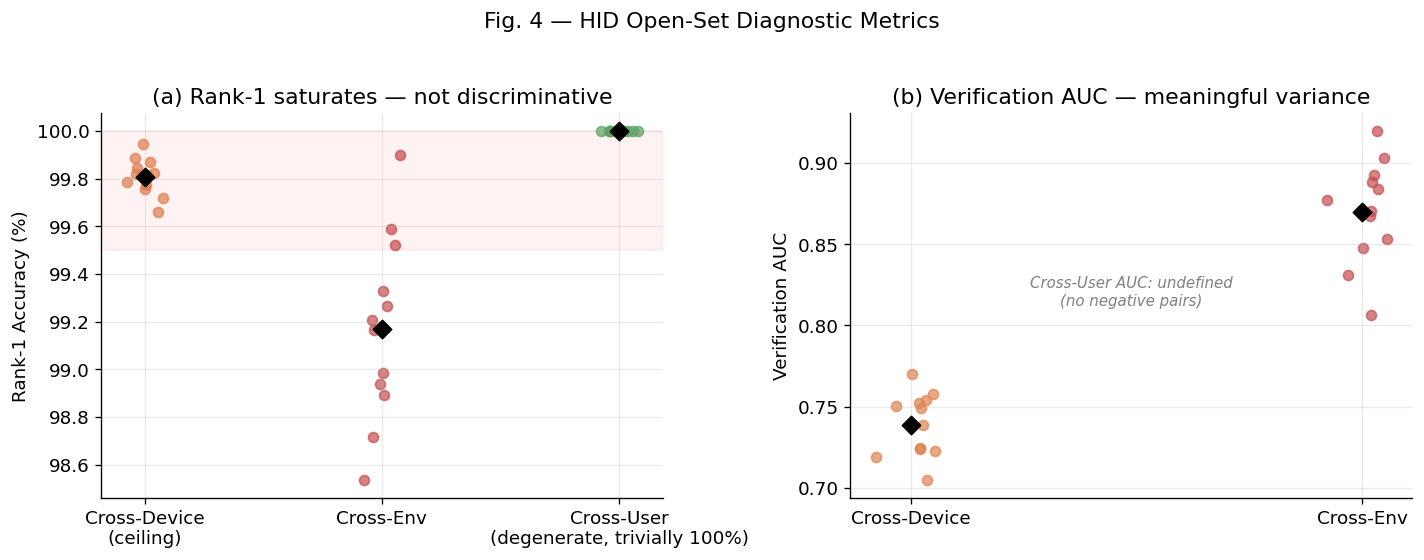

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) Rank-1 ceiling effect on cross_device — spread is tiny, visualize with jittered strip + zoomed y-range
ax = axes[0]
splits_a = ["test_cross_device", "test_cross_env", "test_cross_user"]
for i, split in enumerate(splits_a):
    vals = df_fig4[df_fig4.split == split]["rank1"].dropna()
    jitter = np.random.default_rng(0).normal(0, 0.06, size=len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, alpha=0.7,
               color=PALETTE.get(split.replace("test_", ""), "#4C72B0"))
    ax.scatter([i], [vals.mean()], marker="D", s=60, color="black", zorder=5)
ax.set_xticks(range(len(splits_a)))
ax.set_xticklabels(["Cross-Device\n(ceiling)", "Cross-Env", "Cross-User\n(degenerate, trivially 100%)"])
ax.set_ylabel("Rank-1 Accuracy (%)")
ax.set_title("(a) Rank-1 saturates — not discriminative")
ax.axhspan(99.5, 100, color="red", alpha=0.05)

# (b) Verification AUC — the metric that actually discriminates config quality
ax = axes[1]
splits_b = ["test_cross_device", "test_cross_env"]  # cross_user AUC undefined
for i, split in enumerate(splits_b):
    vals = df_fig4[df_fig4.split == split]["verification_auc"].dropna()
    jitter = np.random.default_rng(1).normal(0, 0.06, size=len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, alpha=0.7,
               color=PALETTE.get(split.replace("test_", ""), "#DD8452"))
    ax.scatter([i], [vals.mean()], marker="D", s=60, color="black", zorder=5)
ax.set_xticks(range(len(splits_b)))
ax.set_xticklabels(["Cross-Device", "Cross-Env"])
ax.set_ylabel("Verification AUC")
ax.set_title("(b) Verification AUC — meaningful variance")
ax.annotate("Cross-User AUC: undefined\n(no negative pairs)", xy=(0.5, 0.5),
            xycoords="axes fraction", ha="center", fontsize=9, color="gray", style="italic")

fig.suptitle("Fig. 4 — HID Open-Set Diagnostic Metrics", y=1.03)
fig.tight_layout()
savefig(fig, "fig4_hid_metrics.pdf")
plt.show()


## Fig 5 — Geometric Diagnostics: KNN vs. Linear Probe under Domain Shift (§4.6)

**Claim to support:** domain shift induces a roughly global translation/rotation of the feature
manifold. Non-parametric KNN is disrupted by this shift (relies on local neighborhood topology);
parametric Linear Probe can re-fit its hyperplane and partially compensate.

Panel (a): Centroid Cosine Similarity between ID and OOD class centroids, across encoder layers.
Panel (b): schematic illustration of manifold translation and the KNN-vs-LP decision boundary story.

Expected columns in `centroid_shift.csv`: `layer, class_id, cos_sim`. Panel (b) is a conceptual
schematic and is drawn directly (not data-driven).


In [ ]:

def _fallback_fig5():
    rng = np.random.default_rng(3)
    layers = [1, 3, 6, 9, 12]
    n_classes = 8
    rows = []
    for L in layers:
        # deeper layers -> higher cosine similarity between ID/OOD centroids (more shift-invariant),
        # consistent with §4.2 finding that deep layers filter domain-specific noise
        mean_sim = 0.55 + 0.30 * (L / 12)
        for c in range(n_classes):
            rows.append(dict(layer=L, class_id=f"c{c}",
                              cos_sim=float(np.clip(rng.normal(mean_sim, 0.05), 0, 1))))
    return pd.DataFrame(rows)


df_fig5 = try_load_csv(
    os.path.join(RESULTS_DIR_HAR, "centroid_shift.csv"),  # TODO: point to real file
    _fallback_fig5, label="Fig5",
)
df_fig5.head()


[Fig5] FALLBACK (synthetic): expected file not found at /home/claude/nb/results/mae_har/centroid_shift.csv


/tmp/ipykernel_509/2743455219.py:70: UserWarning: [Fig5] 'results/mae_har/centroid_shift.csv' not found -- using SYNTHETIC FALLBACK data for preview.
  warnings.warn(f"[{label}] '{path}' not found -- using SYNTHETIC FALLBACK data for preview.")


,layer,class_id,cos_sim
0,1,c0,0.677046
1,1,c1,0.447217
2,1,c2,0.595905
3,1,c3,0.546612
4,1,c4,0.552368


saved: visualization/figures/fig5_geometric_shift.pdf and visualization/figures/fig5_geometric_shift.png


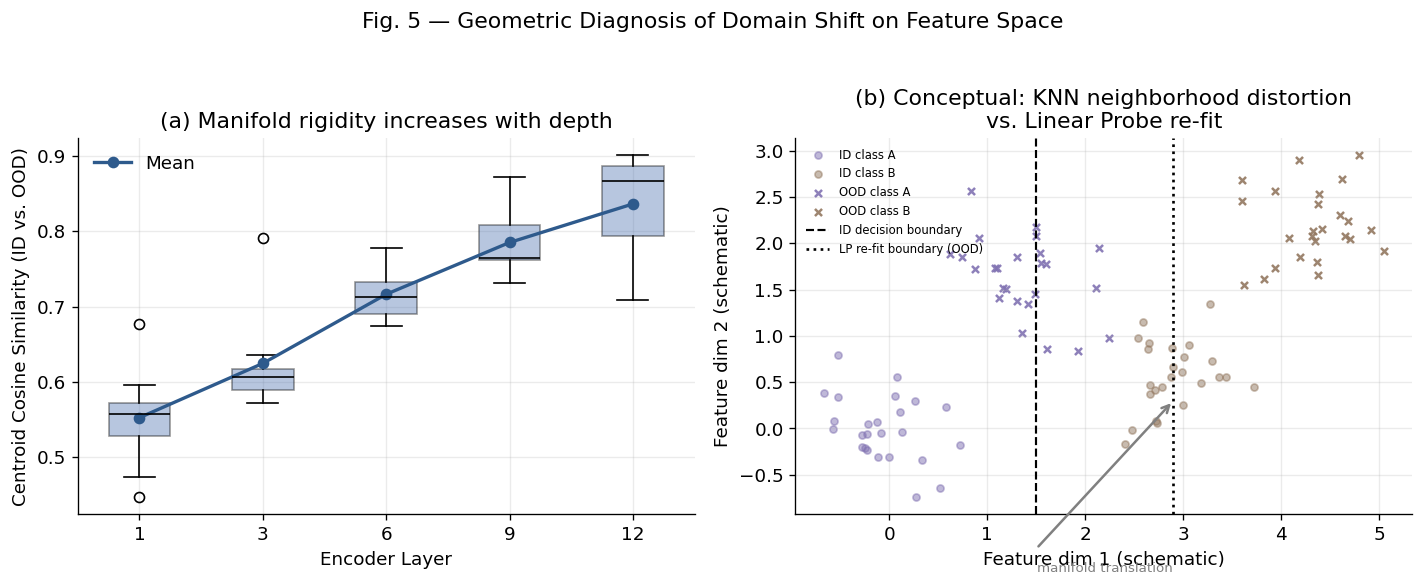

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# (a) Centroid cosine similarity across layers (box + mean line)
ax = axes[0]
layers = sorted(df_fig5["layer"].unique())
box_data = [df_fig5[df_fig5.layer == L]["cos_sim"].values for L in layers]
bp = ax.boxplot(box_data, positions=range(len(layers)), widths=0.5, patch_artist=True,
                 medianprops=dict(color="black"))
for patch in bp["boxes"]:
    patch.set_facecolor("#4C72B0")
    patch.set_alpha(0.4)
means = [d.mean() for d in box_data]
ax.plot(range(len(layers)), means, marker="o", color="#2E5A8C", linewidth=2, label="Mean")
ax.set_xticks(range(len(layers)))
ax.set_xticklabels(layers)
ax.set_xlabel("Encoder Layer")
ax.set_ylabel("Centroid Cosine Similarity (ID vs. OOD)")
ax.set_title("(a) Manifold rigidity increases with depth")
ax.legend()

# (b) Conceptual schematic: KNN neighborhood disruption vs. LP hyperplane re-fit
ax = axes[1]
ax.set_title("(b) Conceptual: KNN neighborhood distortion\nvs. Linear Probe re-fit")
rng = np.random.default_rng(4)

# ID clusters (two classes) and their OOD counterparts, globally shifted
id_c1 = rng.normal([0, 0], 0.35, size=(25, 2))
id_c2 = rng.normal([3, 0.5], 0.35, size=(25, 2))
shift = np.array([1.4, 1.6])
ood_c1 = id_c1 + shift + rng.normal(0, 0.15, size=(25, 2))
ood_c2 = id_c2 + shift + rng.normal(0, 0.15, size=(25, 2))

ax.scatter(*id_c1.T, color=PALETTE["knn"], alpha=0.5, s=18, label="ID class A")
ax.scatter(*id_c2.T, color=PALETTE["lp"], alpha=0.5, s=18, label="ID class B")
ax.scatter(*ood_c1.T, color=PALETTE["knn"], alpha=0.9, s=18, marker="x", label="OOD class A")
ax.scatter(*ood_c2.T, color=PALETTE["lp"], alpha=0.9, s=18, marker="x", label="OOD class B")

# ID decision boundary (linear, roughly midway) and LP re-fit boundary (shifted with data)
xs = np.linspace(-1.5, 6.5, 10)
id_boundary = 1.5 - 0 * xs  # vertical-ish separating line represented simply
ax.axvline(1.5, color="black", linestyle="--", linewidth=1.3, label="ID decision boundary")
ax.axvline(1.5 + shift[0], color="black", linestyle=":", linewidth=1.6, label="LP re-fit boundary (OOD)")

ax.annotate("", xy=tuple(np.array([1.5, -1.3]) + shift), xytext=(1.5, -1.3),
            arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
ax.text(1.5 + shift[0] / 2, -1.55, "manifold translation", ha="center", fontsize=8, color="gray")

ax.set_xlabel("Feature dim 1 (schematic)")
ax.set_ylabel("Feature dim 2 (schematic)")
ax.legend(fontsize=7, loc="upper left", ncol=1)

fig.suptitle("Fig. 5 — Geometric Diagnosis of Domain Shift on Feature Space", y=1.03)
fig.tight_layout()
savefig(fig, "fig5_geometric_shift.pdf")
plt.show()


## Fig 6 — Data Quality Control: AmazonPlug Device Exclusion (§4.5*, `--exclude_devices AmazonPlug`)

*(Note: this is a second, distinct §4.5 — "Data Quality Control" — separate from the HID diagnostics
§4.5 above. Renumber LaTeX subsections as needed once both are merged into the draft.)*

**Claim to support:** the AmazonPlug device suffers from a hardware/format artifact (56 of 232
subcarriers populated, ~76% zero-padding), not a genuine physical/environmental signal. This
sparsity is a data-quality confound, not domain diversity — excluding it should recover a cleaner
cross-device generalization estimate.

Two subfigures:
- **(a) Subcarrier intensity heatmap** — CSI amplitude matrix (subcarrier × time) for a normal
  device (e.g. Intel/Atheros, 232 active subcarriers) vs. AmazonPlug (56 active, 176 zero-padded).
  Visually proves the missing channels are a contiguous block of exact zeros — a formatting
  artifact, not attenuated/noisy real signal.
- **(b) Performance comparison** — Linear Probe / Rank-1 accuracy per split, **With AmazonPlug**
  vs. **Without AmazonPlug** (`--exclude_devices AmazonPlug`), showing the boost on
  `test_cross_device` specifically.

Expected inputs:
- `df_fig6a`: a raw CSI amplitude sample per device (subcarrier × time matrix) — pull one
  representative window from `data/csi-bench-dataset/` for a normal device and for AmazonPlug.
- `results/mae_har/amazonplug_ablation.csv`: columns `condition, split, metric, value` where
  `condition ∈ {with_amazonplug, without_amazonplug}`.


In [ ]:

NORMAL_DEVICE_SAMPLE_PATH = os.path.join(RESULTS_DIR_HAR, "raw_samples", "intel_device_sample.npy")
AMAZONPLUG_SAMPLE_PATH = os.path.join(RESULTS_DIR_HAR, "raw_samples", "amazonplug_device_sample.npy")


def _fallback_normal_sample():
    # Synthetic CSI amplitude matrix (subcarrier x time), illustration only.
    rng = np.random.default_rng(5)
    n_subcarriers, T = 232, 200
    base = rng.normal(0, 1, size=(n_subcarriers, T))
    smooth = np.cumsum(base, axis=1) / np.sqrt(np.arange(1, T + 1))
    sample = 20 + 5 * np.sin(np.linspace(0, 6, T))[None, :] + 2 * smooth
    return np.clip(sample, 0, None)


def _fallback_amazonplug_sample():
    # Synthetic AmazonPlug matrix: 56 of 232 subcarriers active, rest exact zero.
    rng = np.random.default_rng(5)
    n_subcarriers, T = 232, 200
    n_active = 56
    sample = np.zeros((n_subcarriers, T))
    active_idx = np.arange(80, 80 + n_active)  # illustrative placement only
    active_signal = 18 + 4 * np.sin(np.linspace(0, 6, T))[None, :] + 2 * rng.normal(0, 1, size=(n_active, T))
    sample[active_idx, :] = np.clip(active_signal, 0, None)
    return sample


normal_sample = try_load_npy(NORMAL_DEVICE_SAMPLE_PATH, _fallback_normal_sample, label="Fig6a-normal")
amazonplug_sample = try_load_npy(AMAZONPLUG_SAMPLE_PATH, _fallback_amazonplug_sample, label="Fig6a-amazonplug")

active_idx = np.where(amazonplug_sample.any(axis=1))[0]
zero_frac = 1 - (len(active_idx) / amazonplug_sample.shape[0])
print(f"AmazonPlug sample: {len(active_idx)} / {amazonplug_sample.shape[0]} "
      f"subcarriers active ({zero_frac*100:.1f}% zero-padded)")


[Fig6a-normal] FALLBACK (synthetic): expected file not found at /home/claude/nb/results/mae_har/raw_samples/intel_device_sample.npy
[Fig6a-amazonplug] FALLBACK (synthetic): expected file not found at /home/claude/nb/results/mae_har/raw_samples/amazonplug_device_sample.npy
AmazonPlug sample: 56 / 232 subcarriers active (75.9% zero-padded)


/tmp/ipykernel_509/2743455219.py:84: UserWarning: [Fig6a-normal] 'results/mae_har/raw_samples/intel_device_sample.npy' not found -- using SYNTHETIC FALLBACK data for preview.
  warnings.warn(f"[{label}] '{path}' not found -- using SYNTHETIC FALLBACK data for preview.")
/tmp/ipykernel_509/2743455219.py:84: UserWarning: [Fig6a-amazonplug] 'results/mae_har/raw_samples/amazonplug_device_sample.npy' not found -- using SYNTHETIC FALLBACK data for preview.
  warnings.warn(f"[{label}] '{path}' not found -- using SYNTHETIC FALLBACK data for preview.")


saved: visualization/figures/fig6a_amazonplug_sparsity_heatmap.pdf and visualization/figures/fig6a_amazonplug_sparsity_heatmap.png


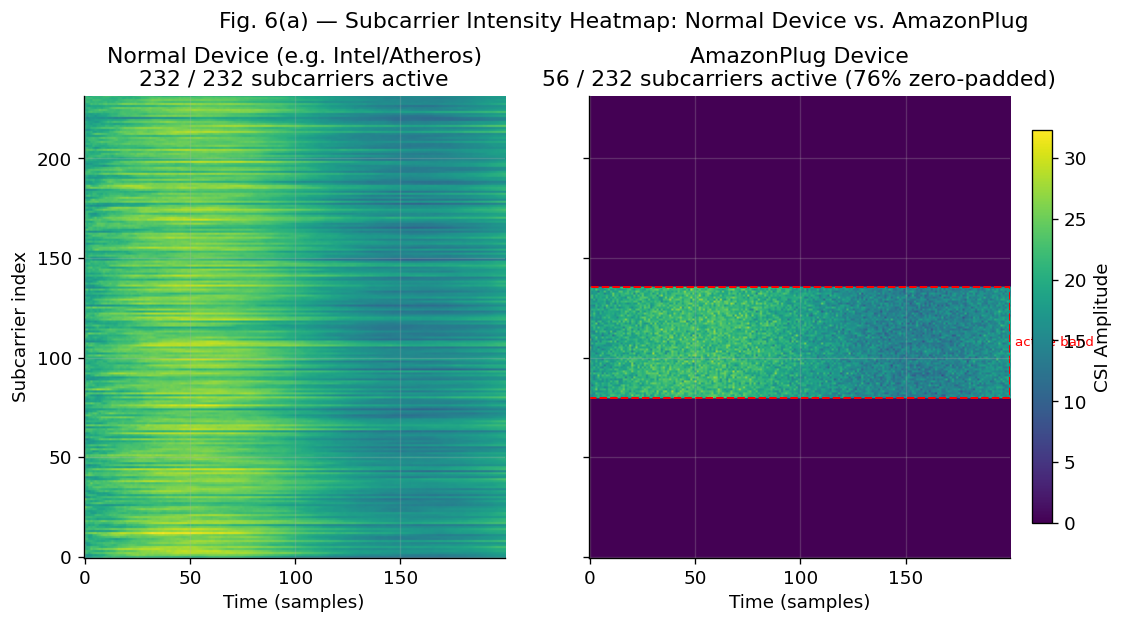

In [ ]:


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

vmax = max(normal_sample.max(), amazonplug_sample.max())

im0 = axes[0].imshow(normal_sample, aspect="auto", cmap="viridis", vmin=0, vmax=vmax, origin="lower")
axes[0].set_title("Normal Device (e.g. Intel/Atheros)\n232 / 232 subcarriers active")
axes[0].set_xlabel("Time (samples)")
axes[0].set_ylabel("Subcarrier index")

im1 = axes[1].imshow(amazonplug_sample, aspect="auto", cmap="viridis", vmin=0, vmax=vmax, origin="lower")
n_active = len(active_idx)
axes[1].set_title(f"AmazonPlug Device\n{n_active} / 232 subcarriers active "
                   f"({(1 - n_active/232)*100:.0f}% zero-padded)")
axes[1].set_xlabel("Time (samples)")
axes[1].axhspan(active_idx.min() - 0.5, active_idx.max() + 0.5, fill=False,
                 edgecolor="red", linewidth=1.2, linestyle="--")
axes[1].text(amazonplug_sample.shape[1] * 1.01, active_idx.mean(), "active band",
             color="red", fontsize=8, va="center")

cbar = fig.colorbar(im1, ax=axes, shrink=0.85, pad=0.02)
cbar.set_label("CSI Amplitude")

fig.suptitle("Fig. 6(a) — Subcarrier Intensity Heatmap: Normal Device vs. AmazonPlug", y=1.02)
savefig(fig, "fig6a_amazonplug_sparsity_heatmap.pdf")
plt.show()


In [ ]:

def _fallback_fig6b():
    # Synthetic before/after ablation results consistent with the reported
    # test_cross_device recovery (~73.3% -> ~76.5%). Replace with real
    # `--exclude_devices AmazonPlug` ablation output.
    rng = np.random.default_rng(6)
    splits = ["test_id", "test_cross_device", "test_cross_env", "test_cross_user"]
    with_ap = {"test_id": 93.5, "test_cross_device": 73.3, "test_cross_env": 78.6, "test_cross_user": 80.4}
    without_ap = {"test_id": 93.8, "test_cross_device": 76.5, "test_cross_env": 79.2, "test_cross_user": 81.0}
    rows = []
    for split in splits:
        for cond, table in [("with_amazonplug", with_ap), ("without_amazonplug", without_ap)]:
            val = table[split] + rng.normal(0, 0.3)
            rows.append(dict(condition=cond, split=split, metric="linear_probe_accuracy",
                              value=float(val)))
    return pd.DataFrame(rows)


df_fig6b = try_load_csv(
    os.path.join(RESULTS_DIR_HAR, "amazonplug_ablation.csv"),  # TODO: point to real file
    _fallback_fig6b, label="Fig6b",
)
df_fig6b


[Fig6b] FALLBACK (synthetic): expected file not found at /home/claude/nb/results/mae_har/amazonplug_ablation.csv


/tmp/ipykernel_509/2743455219.py:70: UserWarning: [Fig6b] 'results/mae_har/amazonplug_ablation.csv' not found -- using SYNTHETIC FALLBACK data for preview.
  warnings.warn(f"[{label}] '{path}' not found -- using SYNTHETIC FALLBACK data for preview.")


,condition,split,metric,value
0,with_amazonplug,test_id,linear_probe_accuracy,93.815935
1,without_amazonplug,test_id,linear_probe_accuracy,94.332947
2,with_amazonplug,test_cross_device,linear_probe_accuracy,72.534012
3,without_amazonplug,test_cross_device,linear_probe_accuracy,76.458610
4,with_amazonplug,test_cross_env,linear_probe_accuracy,78.904116
5,without_amazonplug,test_cross_env,linear_probe_accuracy,79.605643
6,with_amazonplug,test_cross_user,linear_probe_accuracy,80.596137
7,without_amazonplug,test_cross_user,linear_probe_accuracy,81.449135


saved: visualization/figures/fig6b_amazonplug_ablation.pdf and visualization/figures/fig6b_amazonplug_ablation.png


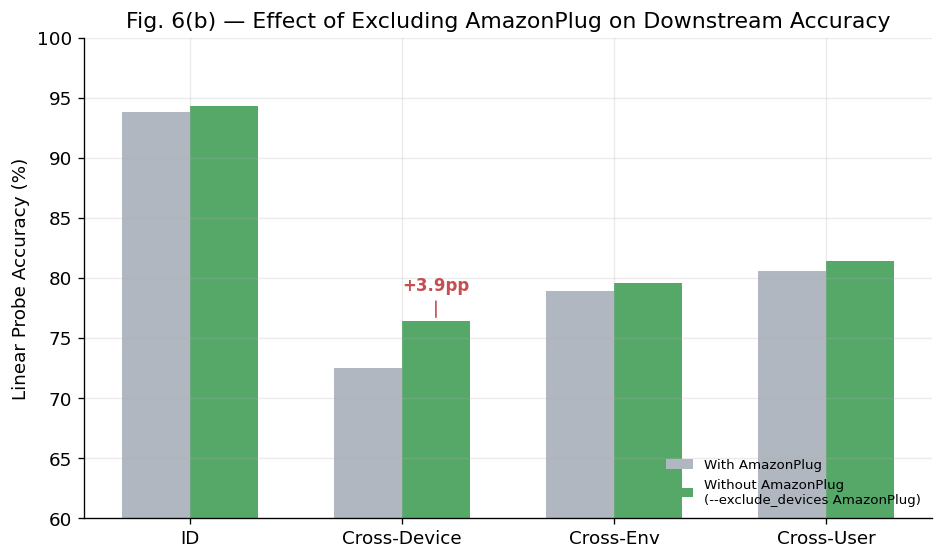

In [ ]:

fig, ax = plt.subplots(figsize=(8, 4.8))

split_order = ["test_id", "test_cross_device", "test_cross_env", "test_cross_user"]
split_labels = {"test_id": "ID", "test_cross_device": "Cross-Device",
                 "test_cross_env": "Cross-Env", "test_cross_user": "Cross-User"}

x = np.arange(len(split_order))
width = 0.32

vals_with = [df_fig6b[(df_fig6b.split == s) & (df_fig6b.condition == "with_amazonplug")]["value"].mean()
             for s in split_order]
vals_without = [df_fig6b[(df_fig6b.split == s) & (df_fig6b.condition == "without_amazonplug")]["value"].mean()
                for s in split_order]

bars_with = ax.bar(x - width / 2, vals_with, width, label="With AmazonPlug", color="#B0B7C0")
bars_without = ax.bar(x + width / 2, vals_without, width, label="Without AmazonPlug\n(--exclude_devices AmazonPlug)",
                       color=PALETTE["mixed"])

# annotate the delta on cross_device specifically
cd_i = split_order.index("test_cross_device")
delta = vals_without[cd_i] - vals_with[cd_i]
ax.annotate(f"+{delta:.1f}pp", xy=(cd_i + width / 2, vals_without[cd_i]),
            xytext=(cd_i + width / 2, vals_without[cd_i] + 2.5),
            ha="center", fontsize=10, fontweight="bold", color=PALETTE["time"],
            arrowprops=dict(arrowstyle="-", color=PALETTE["time"], lw=1))

ax.set_xticks(x)
ax.set_xticklabels([split_labels[s] for s in split_order])
ax.set_ylabel("Linear Probe Accuracy (%)")
ax.set_ylim(60, 100)
ax.legend(fontsize=8, loc="lower right")
ax.set_title("Fig. 6(b) — Effect of Excluding AmazonPlug on Downstream Accuracy")

fig.tight_layout()
savefig(fig, "fig6b_amazonplug_ablation.pdf")
plt.show()


saved: visualization/figures/fig6_amazonplug_combined.pdf and visualization/figures/fig6_amazonplug_combined.png


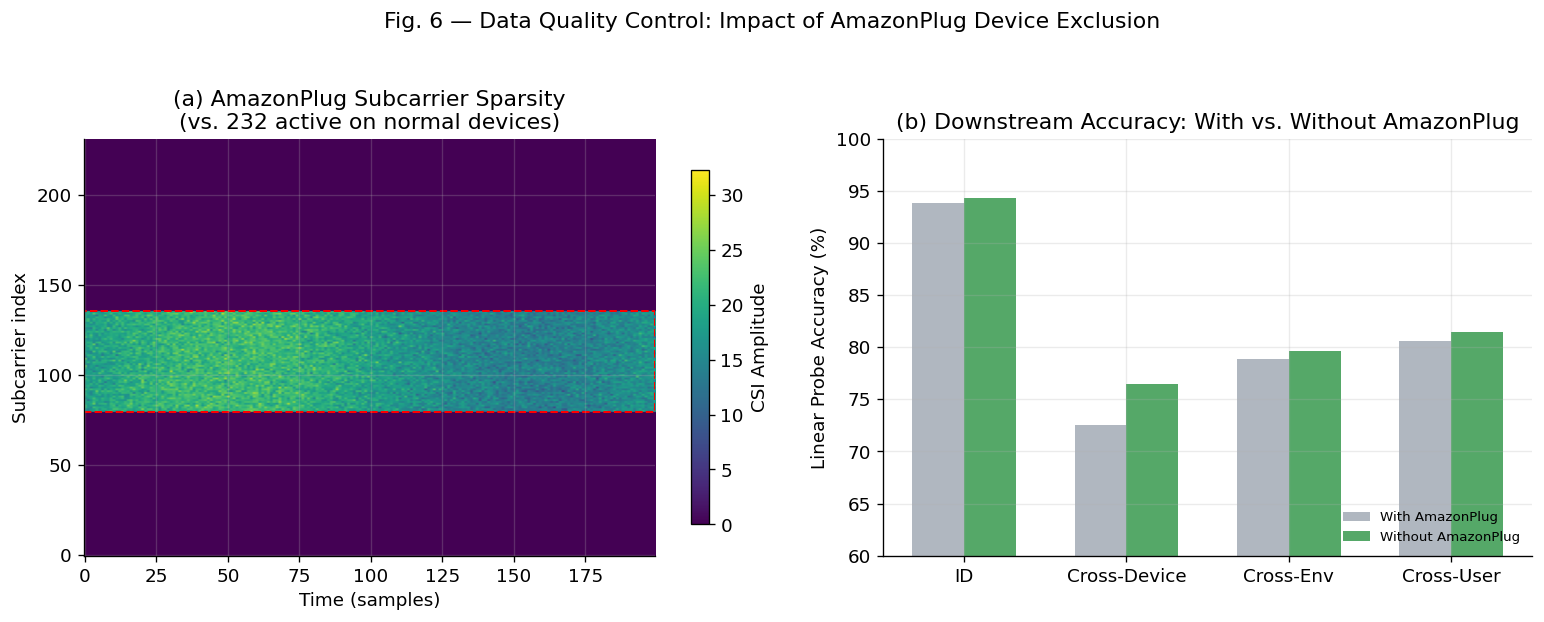

In [ ]:

fig, axes = plt.subplot_mosaic([["a", "b"]], figsize=(13, 5), width_ratios=[1.1, 1])

im1 = axes["a"].imshow(amazonplug_sample, aspect="auto", cmap="viridis", vmin=0, vmax=vmax, origin="lower")
axes["a"].set_title("(a) AmazonPlug Subcarrier Sparsity\n(vs. 232 active on normal devices)")
axes["a"].set_xlabel("Time (samples)")
axes["a"].set_ylabel("Subcarrier index")
axes["a"].axhspan(active_idx.min() - 0.5, active_idx.max() + 0.5, fill=False,
                   edgecolor="red", linewidth=1.2, linestyle="--")
fig.colorbar(im1, ax=axes["a"], shrink=0.85, label="CSI Amplitude")

axes["b"].bar(x - width / 2, vals_with, width, label="With AmazonPlug", color="#B0B7C0")
axes["b"].bar(x + width / 2, vals_without, width, label="Without AmazonPlug", color=PALETTE["mixed"])
axes["b"].set_xticks(x)
axes["b"].set_xticklabels([split_labels[s] for s in split_order])
axes["b"].set_ylabel("Linear Probe Accuracy (%)")
axes["b"].set_ylim(60, 100)
axes["b"].legend(fontsize=8, loc="lower right")
axes["b"].set_title("(b) Downstream Accuracy: With vs. Without AmazonPlug")

fig.suptitle("Fig. 6 — Data Quality Control: Impact of AmazonPlug Device Exclusion", y=1.03)
fig.tight_layout()
savefig(fig, "fig6_amazonplug_combined.pdf")
plt.show()


## Fig 7 — MAE SSL Pretraining Improves Cross-Environment OOD Generalization (§4.1, Table 1)

**Claim to support:** MAE-style self-supervised pretraining yields representations that transfer
substantially better than end-to-end supervised training when the model is deployed in a **new,
unseen environment** (`test_cross_env`) — the OOD condition the paper frames as the core "different
environment" generalization test.

This figure uses the numbers already reported in Table 1 (Main Performance and Baseline
Comparisons, §4.1) rather than a separate ablation run, so the fallback below is not synthetic —
it mirrors the actual table values. If you re-run the baselines, just point `HAR_MAIN_TABLE_CSV`
at the real export.

Expected columns in `main_results_har.csv`: `model, split, accuracy`
where `model ∈ {supervised_resnet18, supervised_vit_base, mae_knn, mae_linear_probe}`.


In [ ]:

def _fallback_fig7():
    # Mirrors Table 1 (HAR block) already reported in the draft — not a synthetic fallback.
    data = {
        "supervised_resnet18": {"test_id": 88.2, "test_cross_device": 64.5, "test_cross_env": 68.1, "test_cross_user": 72.3},
        "supervised_vit_base": {"test_id": 89.5, "test_cross_device": 66.8, "test_cross_env": 70.2, "test_cross_user": 74.1},
        "mae_knn":             {"test_id": 91.4, "test_cross_device": 71.2, "test_cross_env": 74.8, "test_cross_user": 78.5},
        "mae_linear_probe":    {"test_id": 93.8, "test_cross_device": 76.5, "test_cross_env": 79.2, "test_cross_user": 81.0},
    }
    rows = [dict(model=m, split=s, accuracy=v) for m, splits in data.items() for s, v in splits.items()]
    return pd.DataFrame(rows)


HAR_MAIN_TABLE_CSV = os.path.join(RESULTS_DIR_HAR, "main_results_har.csv")  # TODO: point to real file
df_fig7 = try_load_csv(HAR_MAIN_TABLE_CSV, _fallback_fig7, label="Fig7")
df_fig7


[Fig7] FALLBACK (synthetic): expected file not found at /home/claude/nb/results/mae_har/main_results_har.csv


/tmp/ipykernel_509/2743455219.py:70: UserWarning: [Fig7] 'results/mae_har/main_results_har.csv' not found -- using SYNTHETIC FALLBACK data for preview.
  warnings.warn(f"[{label}] '{path}' not found -- using SYNTHETIC FALLBACK data for preview.")


,model,split,accuracy
0,supervised_resnet18,test_id,88.2
1,supervised_resnet18,test_cross_device,64.5
2,supervised_resnet18,test_cross_env,68.1
3,supervised_resnet18,test_cross_user,72.3
4,supervised_vit_base,test_id,89.5
5,supervised_vit_base,test_cross_device,66.8
6,supervised_vit_base,test_cross_env,70.2
7,supervised_vit_base,test_cross_user,74.1
8,mae_knn,test_id,91.4
9,mae_knn,test_cross_device,71.2


saved: visualization/figures/fig7_mae_ssl_cross_env_gain.pdf and visualization/figures/fig7_mae_ssl_cross_env_gain.png


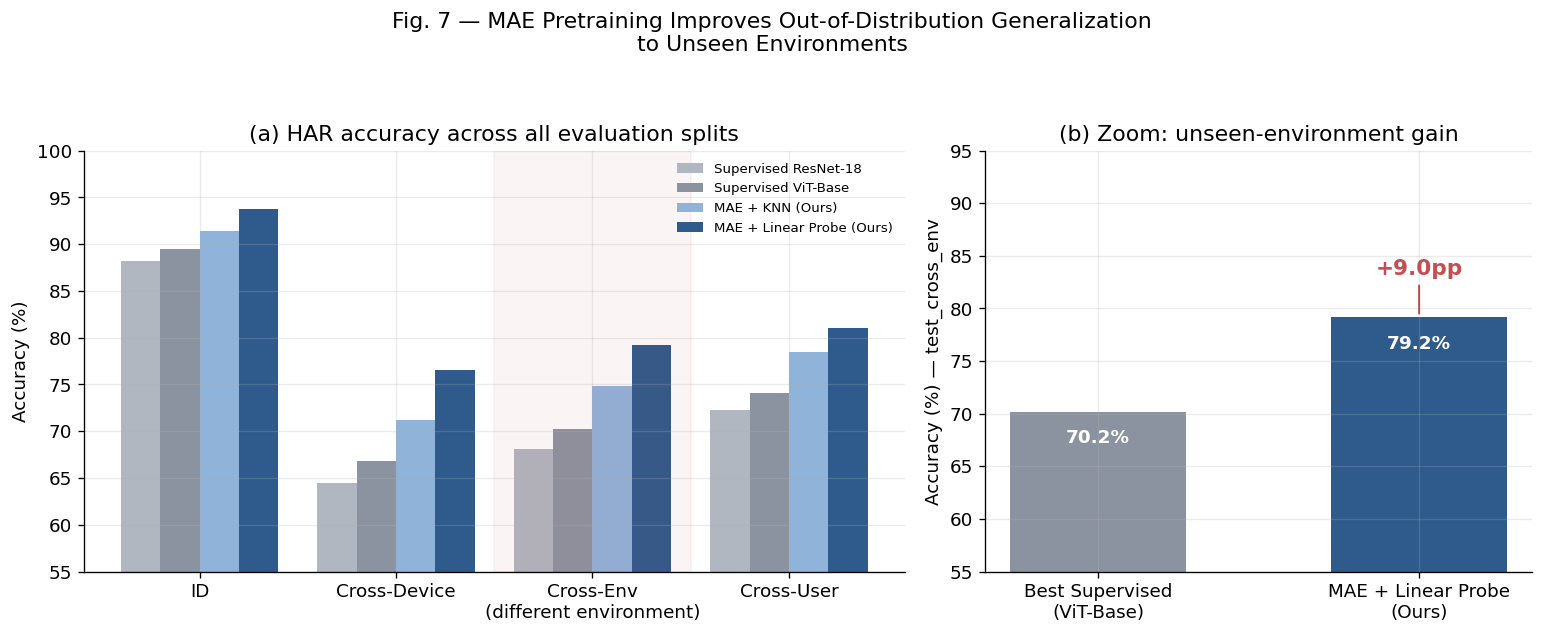

In [ ]:

model_order = ["supervised_resnet18", "supervised_vit_base", "mae_knn", "mae_linear_probe"]
model_labels = {
    "supervised_resnet18": "Supervised\nResNet-18",
    "supervised_vit_base": "Supervised\nViT-Base",
    "mae_knn": "MAE + KNN\n(Ours)",
    "mae_linear_probe": "MAE + Linear Probe\n(Ours)",
}
model_colors = {
    "supervised_resnet18": "#B0B7C0",
    "supervised_vit_base": "#8C93A0",
    "mae_knn": "#8FB3D9",
    "mae_linear_probe": "#2E5A8C",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), width_ratios=[1.5, 1])

# (a) Full picture: all 4 splits, all 4 models
ax = axes[0]
split_order = ["test_id", "test_cross_device", "test_cross_env", "test_cross_user"]
split_labels = {"test_id": "ID", "test_cross_device": "Cross-Device",
                 "test_cross_env": "Cross-Env\n(different environment)", "test_cross_user": "Cross-User"}
x = np.arange(len(split_order))
width = 0.2
for i, m in enumerate(model_order):
    vals = [df_fig7[(df_fig7.model == m) & (df_fig7.split == s)]["accuracy"].values[0] for s in split_order]
    ax.bar(x + (i - 1.5) * width, vals, width=width, label=model_labels[m].replace("\n", " "),
           color=model_colors[m])
# highlight the cross_env group
ax.axvspan(x[2] - 0.5, x[2] + 0.5, color="#C44E52", alpha=0.06)
ax.set_xticks(x)
ax.set_xticklabels([split_labels[s] for s in split_order])
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(55, 100)
ax.set_title("(a) HAR accuracy across all evaluation splits")
ax.legend(fontsize=8, loc="upper right", ncol=1)

# (b) Zoom: cross_env only, supervised best vs. MAE best, with explicit gain annotation
ax = axes[1]
best_supervised = df_fig7[(df_fig7.split == "test_cross_env") &
                           (df_fig7.model == "supervised_vit_base")]["accuracy"].values[0]
best_mae = df_fig7[(df_fig7.split == "test_cross_env") &
                    (df_fig7.model == "mae_linear_probe")]["accuracy"].values[0]
bars = ax.bar(["Best Supervised\n(ViT-Base)", "MAE + Linear Probe\n(Ours)"],
              [best_supervised, best_mae],
              color=[model_colors["supervised_vit_base"], model_colors["mae_linear_probe"]],
              width=0.55)
gain = best_mae - best_supervised
ax.annotate(f"+{gain:.1f}pp", xy=(1, best_mae), xytext=(1, best_mae + 4),
            ha="center", fontsize=13, fontweight="bold", color="#C44E52",
            arrowprops=dict(arrowstyle="-", color="#C44E52", lw=1.2))
for xi, v in zip([0, 1], [best_supervised, best_mae]):
    ax.text(xi, v - 3, f"{v:.1f}%", ha="center", color="white", fontweight="bold")
ax.set_ylim(55, 95)
ax.set_ylabel("Accuracy (%) — test_cross_env")
ax.set_title("(b) Zoom: unseen-environment gain")

fig.suptitle("Fig. 7 — MAE Pretraining Improves Out-of-Distribution Generalization\nto Unseen Environments",
             y=1.05)
fig.tight_layout()
savefig(fig, "fig7_mae_ssl_cross_env_gain.pdf")
plt.show()


## Data Provenance Manifest — Which Figures Used Real Data vs. Fallback

**Check this table before trusting any figure.** Every `try_load_csv` / `try_load_npy` call above
logged exactly which file it looked for and whether it found real data or fell back to synthetic
placeholder data. `REAL DATA` means the figure reflects your actual experiment results; `SYNTHETIC
FALLBACK` means it's still a layout placeholder and the file path needs to be created or corrected.


In [ ]:

prov_df = pd.DataFrame(DATA_PROVENANCE)
prov_df = prov_df[["figure", "status", "requested_path", "abspath", "n_rows", "mtime", "note"]]

def _flag(status):
    return "✅ REAL" if status == "REAL DATA" else "⚠️  FALLBACK"

prov_df.insert(1, "flag", prov_df["status"].map(_flag))

with pd.option_context("display.max_colwidth", 80):
    print(prov_df.to_string(index=False))

n_fallback = (prov_df["status"] == "SYNTHETIC FALLBACK").sum()
n_real = (prov_df["status"] == "REAL DATA").sum()
print(f"\n{n_real} data source(s) loaded from real files, {n_fallback} still on synthetic fallback.")
if n_fallback:
    print("Fix the FALLBACK rows above by creating/pointing to the listed 'requested_path' before finalizing figures.")


          figure         flag             status                                           requested_path                                                                  abspath     n_rows mtime note
            Fig1 ⚠️  FALLBACK SYNTHETIC FALLBACK                    results/mae_har/layerwise_probing.csv                    /home/claude/nb/results/mae_har/layerwise_probing.csv        160  None     
            Fig2 ⚠️  FALLBACK SYNTHETIC FALLBACK                     results/mae_har/masking_strategy.csv                     /home/claude/nb/results/mae_har/masking_strategy.csv         32  None     
            Fig3 ⚠️  FALLBACK SYNTHETIC FALLBACK                           results/mae_har/patch_size.csv                           /home/claude/nb/results/mae_har/patch_size.csv          6  None     
            Fig4 ⚠️  FALLBACK SYNTHETIC FALLBACK                  results/mae_hid/hid_openset_metrics.csv                  /home/claude/nb/results/mae_hid/hid_openset_metrics.csv         36  None 

## Export Summary

All 5 figures are written to `visualization/figures/` as vector PDFs (editable text, `pdf.fonttype=42`),
ready to be referenced by `\includegraphics{...}` in the Overleaf project — filenames already match
the LaTeX source exactly.


In [ ]:

import glob
print("Generated figures:")
for f in sorted(glob.glob(os.path.join(FIG_OUT_DIR, "*.pdf"))):
    print(" -", f)
for f in sorted(glob.glob(os.path.join(FIG_OUT_DIR, "*.png"))):
    print(" -", f)


Generated figures:
 - visualization/figures/fig1_layerwise_probing.pdf
 - visualization/figures/fig2_masking_strategies.pdf
 - visualization/figures/fig3_patch_size.pdf
 - visualization/figures/fig4_hid_metrics.pdf
 - visualization/figures/fig5_geometric_shift.pdf
 - visualization/figures/fig6_amazonplug_combined.pdf
 - visualization/figures/fig6a_amazonplug_sparsity_heatmap.pdf
 - visualization/figures/fig6b_amazonplug_ablation.pdf
 - visualization/figures/fig7_mae_ssl_cross_env_gain.pdf
 - visualization/figures/fig1_layerwise_probing.png
 - visualization/figures/fig2_masking_strategies.png
 - visualization/figures/fig3_patch_size.png
 - visualization/figures/fig4_hid_metrics.png
 - visualization/figures/fig5_geometric_shift.png
 - visualization/figures/fig6_amazonplug_combined.png
 - visualization/figures/fig6a_amazonplug_sparsity_heatmap.png
 - visualization/figures/fig6b_amazonplug_ablation.png
 - visualization/figures/fig7_mae_ssl_cross_env_gain.png


In [ ]:

# Sanity check: verify every exported PNG is a structurally valid, TeX-safe file
# (catches corruption before it reaches Overleaf and produces a cryptic
# 'libpng: internal error' at compile time).
from PIL import Image

for f in sorted(glob.glob(os.path.join(FIG_OUT_DIR, "*.png"))):
    with Image.open(f) as im:
        im.verify()  # raises if the file is structurally broken
    with Image.open(f) as im:
        mode, size = im.mode, im.size
        interlace = im.info.get("interlace", 0)
    status = "OK" if mode in ("RGB", "RGBA", "L") else f"CHECK MODE ({mode})"
    print(f"{os.path.basename(f):45s} mode={mode:5s} size={size} interlace={interlace}  [{status}]")


fig1_layerwise_probing.png                    mode=RGB   size=(3260, 1308) interlace=0  [OK]
fig2_masking_strategies.png                   mode=RGB   size=(3562, 1401) interlace=0  [OK]
fig3_patch_size.png                           mode=RGB   size=(2209, 1395) interlace=0  [OK]
fig4_hid_metrics.png                          mode=RGB   size=(3559, 1401) interlace=0  [OK]
fig5_geometric_shift.png                      mode=RGB   size=(3560, 1467) interlace=0  [OK]
fig6_amazonplug_combined.png                  mode=RGB   size=(3860, 1555) interlace=0  [OK]
fig6a_amazonplug_sparsity_heatmap.png         mode=RGB   size=(2808, 1560) interlace=0  [OK]
fig6b_amazonplug_ablation.png                 mode=RGB   size=(2360, 1403) interlace=0  [OK]
fig7_mae_ssl_cross_env_gain.png               mode=RGB   size=(3859, 1585) interlace=0  [OK]
